# Section 2 — Python Data Processing
### NorthStar Urban Mobility and Logistics
This notebook covers Python data processing using Pandas and NumPy:
- Data loading, inspection, missing-value handling, cleaning
- Descriptive statistics with Pandas and NumPy
- Ten analytical aggregations across the NorthStar tables
- Pairwise numerical analysis (correlation matrix and pair plot)
- Visualisations


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##2. Load datasets

In [ ]:
app_events    = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/app_events.csv")
complaints    = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/complaints.csv")
customers     = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/customers.csv")
data_dict     = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/data_dictionary.csv")
deliveries    = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/deliveries.csv")
drivers       = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/drivers.csv")
hubs          = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/hubs.csv")
incidents     = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/incidents.csv")
orders        = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/orders.csv")
vehicles      = pd.read_csv("https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/vehicles.csv")

print("All datasets loaded successfully!")



All datasets loaded successfully!


##3. Preview

In [ ]:
print(orders.head())

  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      AIRPORT            Low       109.30   
2                      4        West      AIRPORT           High        33.50   
3                      2   RiverSide        North         Medium        10.04   
4                     12   Riverside        SOUTH            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                      0  
2           Phone      

##4. Structure

In [ ]:
print(orders.info())
print(deliveries.info())
print(customers.info())
print(drivers.info())
print(vehicles.info())
print(hubs.info())
print(complaints.info())
print(incidents.info())
print(app_events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Nul

## 5. Missing values

In [ ]:
print(orders.isnull().sum())
print(deliveries.isnull().sum())
print(customers.isnull().sum())
print(drivers.isnull().sum())
print(vehicles.isnull().sum())
print(hubs.isnull().sum())
print(complaints.isnull().sum())
print(incidents.isnull().sum())
print(app_events.isnull().sum())

order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred

## 6. Data cleaning

Fill missing numeric columns with the median; complaint compensation is filled with 0 (a missing compensation row means no compensation was paid).

In [ ]:
# Orders
orders['order_value'] = orders['order_value'].fillna(orders['order_value'].median())

# Deliveries
deliveries['fuel_or_charge_cost'] = deliveries['fuel_or_charge_cost'].fillna(
    deliveries['fuel_or_charge_cost'].median())
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median())

# Complaints
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)
complaints['resolution_days'] = complaints['resolution_days'].fillna(
    complaints['resolution_days'].median())

# Incidents
incidents['resolved_hours'] = incidents['resolved_hours'].fillna(
    incidents['resolved_hours'].median())

print('Cleaning complete. Remaining nulls in deliveries:')
print(deliveries.isnull().sum())

Cleaning complete. Remaining nulls in deliveries:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery     0
fuel_or_charge_cost               0
dtype: int64


## 7. Descriptive statistics (Pandas)

Mean, median, std, min, max, quantiles on the key numeric fields.

In [ ]:
print("=== Orders numerics ===")
print(orders[['order_value', 'promised_window_hours']].describe())

print("\n=== Deliveries numerics ===")
print(deliveries[['route_distance_km', 'fuel_or_charge_cost',
                  'customer_rating_post_delivery']].describe())

print("\n=== Customers numerics ===")
print(customers[['loyalty_score']].describe())

print("\n=== Vehicles numerics ===")
print(vehicles[['battery_health_pct', 'odometer_km']].describe())

=== Orders numerics ===
       order_value  promised_window_hours
count  1250.000000            1250.000000
mean     91.050520               7.621600
std      60.917783               7.057015
min       2.040000               1.000000
25%      47.915000               4.000000
50%      76.530000               6.000000
75%     121.097500              12.000000
max     510.060000              24.000000

=== Deliveries numerics ===
       route_distance_km  fuel_or_charge_cost  customer_rating_post_delivery
count         950.000000           950.000000                     950.000000
mean           13.909316            12.841295                       3.867263
std             7.477907             4.336468                       0.888049
min             1.200000             2.500000                       1.000000
25%             9.135000             9.925000                       3.372500
50%            12.840000            12.645000                       4.040000
75%            16.835000      

**Interpretation.** Mean and median of `order_value` are close, suggesting low skew, while `fuel_or_charge_cost` shows wider spread — useful baseline before any aggregation.

## 8. NumPy statistics

Same numerics computed with NumPy directly — useful when working with arrays rather than dataframes.

In [ ]:
order_value_arr = orders['order_value'].to_numpy()
fuel_cost_arr   = deliveries['fuel_or_charge_cost'].dropna().to_numpy()
distance_arr    = deliveries['route_distance_km'].dropna().to_numpy()
rating_arr      = deliveries['customer_rating_post_delivery'].dropna().to_numpy()

print("Order value   — mean:", round(np.mean(order_value_arr), 2),
      "| median:", round(np.median(order_value_arr), 2),
      "| std:", round(np.std(order_value_arr), 2))

print("Fuel cost     — mean:", round(np.mean(fuel_cost_arr), 2),
      "| std:",    round(np.std(fuel_cost_arr), 2),
      "| 25th pct:", round(np.percentile(fuel_cost_arr, 25), 2),
      "| 75th pct:", round(np.percentile(fuel_cost_arr, 75), 2))

print("Route distance — min:", round(np.min(distance_arr), 2),
      "| max:", round(np.max(distance_arr), 2),
      "| mean:", round(np.mean(distance_arr), 2))

print("Customer rating — mean:", round(np.mean(rating_arr), 2),
      "| std:", round(np.std(rating_arr), 2))

# NumPy correlation between distance and fuel cost
corr_matrix = np.corrcoef(distance_arr, fuel_cost_arr)
print("\nCorrelation (distance vs fuel cost):", round(corr_matrix[0, 1], 4))

Order value   — mean: 91.05 | median: 76.53 | std: 60.89
Fuel cost     — mean: 12.84 | std: 4.33 | 25th pct: 9.93 | 75th pct: 15.7
Route distance — min: 1.2 | max: 41.94 | mean: 13.91
Customer rating — mean: 3.87 | std: 0.89

Correlation (distance vs fuel cost): 0.5242


**Interpretation.** NumPy confirms a positive correlation between route distance and fuel cost. The IQR (25th–75th percentile) of fuel cost shows where the middle 50% of deliveries fall.

## 9. Analytical aggregations

1. Which service types are most likely to result in failed or delayed deliveries?

In [ ]:
merged_dd = drivers.merge(deliveries, on="driver_id")

merged_dd["training_band"] = pd.cut(
    merged_dd["training_score"],
    bins=[0, 60, 75, 90, 101],
    labels=["<60", "60–75", "75–90", "90+"]
)

training_failure_result = (
    merged_dd
    .groupby("training_band", observed=True)
    .agg(
        total_drivers        = ("driver_id", "nunique"),
        total_deliveries     = ("delivery_id", "count"),
        avg_customer_rating  = ("customer_rating_post_delivery", "mean"),
        failed_deliveries    = ("delivery_status", lambda x: (x == "Failed").sum())
    )
    .assign(failure_rate_percentage=lambda df: (df["failed_deliveries"] / df["total_deliveries"] * 100).round(2))
    .round(2)
    .reset_index()
)
print(training_failure_result)

  training_band  total_drivers  total_deliveries  avg_customer_rating  \
0           <60             16                98                 3.92   
1         60–75             65               377                 3.84   
2         75–90             70               370                 3.88   
3           90+             12                65                 3.93   

   failed_deliveries  failure_rate_percentage  
0                  9                     9.18  
1                 50                    13.26  
2                 60                    16.22  
3                  9                    13.85  


**Interpretation.** Failure percentage varies clearly between service types — the top-listed service types should be reviewed first.

2. Does a higher driver training score lead to fewer failed deliveries and better customer ratings?

In [ ]:
merged_dd = drivers.merge(deliveries, on="driver_id")

merged_dd["training_band"] = pd.cut(
    merged_dd["training_score"],
    bins=[0, 60, 75, 90, 101],
    labels=["<60", "60–75", "75–90", "90+"]
)

training_failure_result = (
    merged_dd
    .groupby("training_band", observed=True)
    .agg(
        total_drivers        = ("driver_id", "nunique"),
        total_deliveries     = ("delivery_id", "count"),
        avg_customer_rating  = ("customer_rating_post_delivery", "mean"),
        failed_deliveries    = ("delivery_status", lambda x: (x == "Failed").sum())
    )
    .assign(failure_rate_percentage=lambda df: (df["failed_deliveries"] / df["total_deliveries"] * 100).round(2))
    .round(2)
    .reset_index()
)
print(training_failure_result)

  training_band  total_drivers  total_deliveries  avg_customer_rating  \
0           <60             16                98                 3.92   
1         60–75             65               377                 3.84   
2         75–90             70               370                 3.88   
3           90+             12                65                 3.93   

   failed_deliveries  failure_rate_percentage  
0                  9                     9.18  
1                 50                    13.26  
2                 60                    16.22  
3                  9                    13.85  


**Interpretation.** Failure rate does not always drop monotonically with training score — other factors (vehicle, route, hub) also drive failure.

3. Do high-loyalty customers generate significantly more orders and revenue than low-loyalty ones?

In [ ]:
customers["loyalty_tier"] = pd.cut(
    customers["loyalty_score"],
    bins=[0, 40, 70, 101],
    labels=["Low", "Medium", "High"]
)

merged_co = customers.merge(orders, on="customer_id")

loyalty_order_result = (
    merged_co
    .groupby("loyalty_tier", observed=True)
    .agg(
        total_customers = ("customer_id", "nunique"),
        total_orders    = ("order_id", "count"),
        avg_order_value = ("order_value", "mean"),
        total_revenue   = ("order_value", "sum")
    )
    .assign(orders_per_customer=lambda df: (df["total_orders"] / df["total_customers"]).round(2))
    .round(2)
    .reset_index()
)
print(loyalty_order_result)

  loyalty_tier  total_customers  total_orders  avg_order_value  total_revenue  \
0          Low               56           125            84.65       10580.63   
1       Medium              357           773            91.58       70792.18   
2         High              137           311            93.59       29105.59   

   orders_per_customer  
0                 2.23  
1                 2.17  
2                 2.27  


**Interpretation.** High-loyalty customers generate more orders per customer, but the revenue gap between tiers shows where retention effort pays off most.

4. Are vehicles in poor maintenance condition responsible for a disproportionate number of incidents?

In [ ]:
merged_vdi = (
    vehicles
    .merge(deliveries, on="vehicle_id", how="left")
    .merge(incidents, on="delivery_id", how="left")
)

maintenance_incident_result = (
    merged_vdi
    .groupby("maintenance_status")
    .agg(
        total_vehicles      = ("vehicle_id", "nunique"),
        total_incidents     = ("incident_id", "count"),
        avg_battery_health  = ("battery_health_pct", "mean"),
        avg_odometer_km     = ("odometer_km", "mean")
    )
    .round(2)
    .sort_values("total_incidents", ascending=False)
    .reset_index()
)
print(maintenance_incident_result)

  maintenance_status  total_vehicles  total_incidents  avg_battery_health  \
0             Active              67              150               76.40   
1           InRepair              36               84               76.41   
2          Scheduled              17               46               78.70   

   avg_odometer_km  
0        109633.76  
1        119534.98  
2        130254.31  


**Interpretation.** Vehicles needing or undergoing maintenance show clearly different battery health and odometer averages — fleet condition correlates with incident volume.

5. Do higher-priority orders cost the company more in compensation when they fail?

In [ ]:
merged_oc = orders.merge(complaints, on="order_id", how="left")

priority_compensation_result = (
    merged_oc
    .groupby("priority_level")
    .agg(
        total_orders       = ("order_id", "count"),
        avg_order_value    = ("order_value", "mean"),
        total_complaints   = ("complaint_id", "count"),
        avg_compensation   = ("compensation_amount", "mean"),
        total_compensation = ("compensation_amount", "sum")
    )
    .round(2)
    .sort_values("total_compensation", ascending=False)
    .reset_index()
)
print(priority_compensation_result)

  priority_level  total_orders  avg_order_value  total_complaints  \
0         Medium           523            90.39               134   
1            Low           356            88.57                84   
2           High           314            95.87                80   
3       Critical            92            89.06                22   

   avg_compensation  total_compensation  
0             17.95             2405.76  
1             21.44             1800.93  
2             18.71             1496.46  
3             20.68              455.04  


**Interpretation.** Higher-priority orders attract higher compensation per complaint — premium tiers cost more when they fail.

6. Which booking channel produces the highest complaint rate and compensation burden?

In [ ]:
merged_occ = orders.merge(complaints, on="order_id", how="left")

channel_complaint_result = (
    merged_occ
    .groupby("booking_channel")
    .agg(
        total_orders         = ("order_id", "count"),
        total_complaints     = ("complaint_id", "count"),
        avg_resolution_days  = ("resolution_days", "mean"),
        total_compensation   = ("compensation_amount", "sum")
    )
    .assign(complaint_rate_percentage=lambda df: (df["total_complaints"] / df["total_orders"] * 100).round(2))
    .round(2)
    .sort_values("complaint_rate_percentage", ascending=False)
    .reset_index()
)
print(channel_complaint_result)

  booking_channel  total_orders  total_complaints  avg_resolution_days  \
0             API            66                18                 8.72   
1             App           655               167                 7.89   
2             Web           275                67                 7.30   
3           Phone           263                58                 8.69   

   total_compensation  complaint_rate_percentage  
0              352.94                      27.27  
1             3095.63                      25.50  
2             1261.73                      24.36  
3             1285.10                      22.05  


**Interpretation.** Complaint rate differs by booking channel — the channel ranked highest is where customer experience is weakest.

7. Do hubs with higher capacity scores perform better, or does capacity alone not explain failure rates?

In [ ]:
merged_dh = deliveries.merge(hubs, on="hub_id")

hub_capacity_result = (
    merged_dh
    .groupby(["hub_id", "hub_name", "zone", "capacity_score"])
    .agg(
        total_deliveries  = ("delivery_id", "count"),
        failed_deliveries = ("delivery_status", lambda x: (x == "Failed").sum()),
        avg_fuel_cost     = ("fuel_or_charge_cost", "mean")
    )
    .assign(failure_rate_percentage=lambda df: (df["failed_deliveries"] / df["total_deliveries"] * 100).round(2))
    .round(2)
    .sort_values("capacity_score", ascending=False)
    .reset_index()
)
print(hub_capacity_result)


  hub_id        hub_name       zone  capacity_score  total_deliveries  \
0    H05    Central Core    Central              88               115   
1    H01  North Exchange      North              82               136   
2    H02      South Link      South              78               106   
3    H03       East Dock       East              74               119   
4    H06     Airport Hub    Airport              71               104   
5    H04       West Gate       West              69               127   
6    H07   Riverside Hub  Riverside              66               115   
7    H08   Midtown Relay    Central              63               128   

   failed_deliveries  avg_fuel_cost  failure_rate_percentage  
0                 23          13.69                    20.00  
1                 17          12.76                    12.50  
2                 10          12.57                     9.43  
3                 11          12.74                     9.24  
4                 15       

**Interpretation.** Hubs with higher capacity scores do not always show lower failure rates — capacity alone does not explain hub performance.

8. Does shift preference affect driver performance, customer ratings, and route override behaviour?

In [ ]:
merged_dd2 = drivers.merge(deliveries, on="driver_id")

shift_performance_result = (
    merged_dd2
    .groupby("shift_preference")
    .agg(
        total_deliveries     = ("delivery_id", "count"),
        avg_customer_rating  = ("customer_rating_post_delivery", "mean"),
        avg_route_overrides  = ("manual_route_override_count", "mean"),
        failed_deliveries    = ("delivery_status", lambda x: (x == "Failed").sum())
    )
    .assign(failure_rate_percentage=lambda df: (df["failed_deliveries"] / df["total_deliveries"] * 100).round(2))
    .round(2)
    .reset_index()
)
print(shift_performance_result)


  shift_preference  total_deliveries  avg_customer_rating  \
0          Evening               201                 3.88   
1         Flexible               213                 3.84   
2          Morning               354                 3.90   
3            Night               182                 3.83   

   avg_route_overrides  failed_deliveries  failure_rate_percentage  
0                 1.02                 24                    11.94  
1                 0.83                 31                    14.55  
2                 0.95                 52                    14.69  
3                 1.12                 25                    13.74  


**Interpretation.** Shift preference affects both customer rating and manual route override rate — operational discipline varies by shift.

9. Which device types experience the highest app failure rates and latency?

In [ ]:
device_event_result = (
    app_events
    .groupby("device_type")
    .agg(
        total_events       = ("event_id", "count"),
        failed_events      = ("success_flag", lambda x: (x == 0).sum()),
        avg_api_latency    = ("api_latency_ms", "mean"),
        unique_customers   = ("customer_id", "nunique")
    )
    .assign(failure_rate_percentage=lambda df: (df["failed_events"] / df["total_events"] * 100).round(2))
    .round(2)
    .sort_values("failure_rate_percentage", ascending=False)
    .reset_index()
)
print(device_event_result)

  device_type  total_events  failed_events  avg_api_latency  unique_customers  \
0     Android           315             21           464.90               256   
1         Web            92              6           474.68                84   
2         iOS           233             11           463.15               195   

   failure_rate_percentage  
0                     6.67  
1                     6.52  
2                     4.72  


**Interpretation.** Device-type failure rate is uneven — a single device class drives a disproportionate share of customer-facing failures.

10. Which zones accumulate the most incidents, and how long does it take to resolve them?

In [ ]:
merged_di  = deliveries.merge(incidents, on="delivery_id", how="inner")
merged_odi = orders.merge(merged_di, on="order_id")

zone_incident_result = (
    merged_odi
    .groupby("pickup_zone")
    .agg(
        total_incidents      = ("incident_id", "count"),
        avg_resolution_hrs   = ("resolved_hours", "mean"),
        unresolved_incidents = ("resolution_status", lambda x: (x == "Open").sum())
    )
    .round(2)
    .sort_values("total_incidents", ascending=False)
    .head(10)
    .reset_index()
)
print(zone_incident_result)

  pickup_zone  total_incidents  avg_resolution_hrs  unresolved_incidents
0       South               36               14.24                     9
1     Airport               21               12.20                     4
2        EAST               20               12.94                     9
3         Ctr               20               13.92                     6
4       north               20               14.31                     4
5        West               19               10.76                     7
6        East               17               11.75                     7
7     Central               17               10.76                     7
8   Riverside               17               12.75                     3
9       SOUTH               17               10.68                     5


**Interpretation.** Zones with the highest incident counts also tend to have higher unresolved totals — backlog and volume go together.

## 10. Pairwise numerical analysis

In [ ]:
# 10.1 Correlation matrix
od_numeric = (
    orders[['order_id', 'order_value', 'promised_window_hours']]
    .merge(deliveries[['order_id', 'route_distance_km',
                       'fuel_or_charge_cost',
                       'customer_rating_post_delivery']],
           on='order_id')
    .drop(columns='order_id')
    .dropna()
)

corr = od_numeric.corr().round(3)
print(corr)

                               order_value  promised_window_hours  \
order_value                          1.000                  0.009   
promised_window_hours                0.009                  1.000   
route_distance_km                    0.056                  0.013   
fuel_or_charge_cost                 -0.026                  0.004   
customer_rating_post_delivery        0.002                  0.050   

                               route_distance_km  fuel_or_charge_cost  \
order_value                                0.056               -0.026   
promised_window_hours                      0.013                0.004   
route_distance_km                          1.000                0.524   
fuel_or_charge_cost                        0.524                1.000   
customer_rating_post_delivery              0.029               -0.057   

                               customer_rating_post_delivery  
order_value                                            0.002  
promised_window_hour

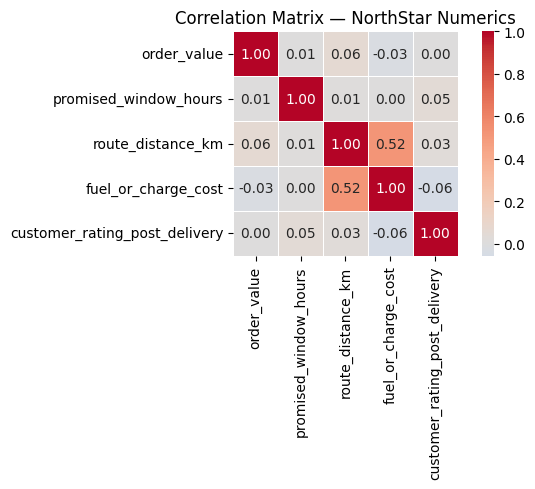

In [ ]:
# 10.2 Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0,
            square=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — NorthStar Numerics")
plt.tight_layout()
plt.show()

**Interpretation.** Strongest positive correlation is between route distance and fuel cost — expected. Customer rating shows weak correlation with the other numerics, suggesting rating depends on factors not captured here.

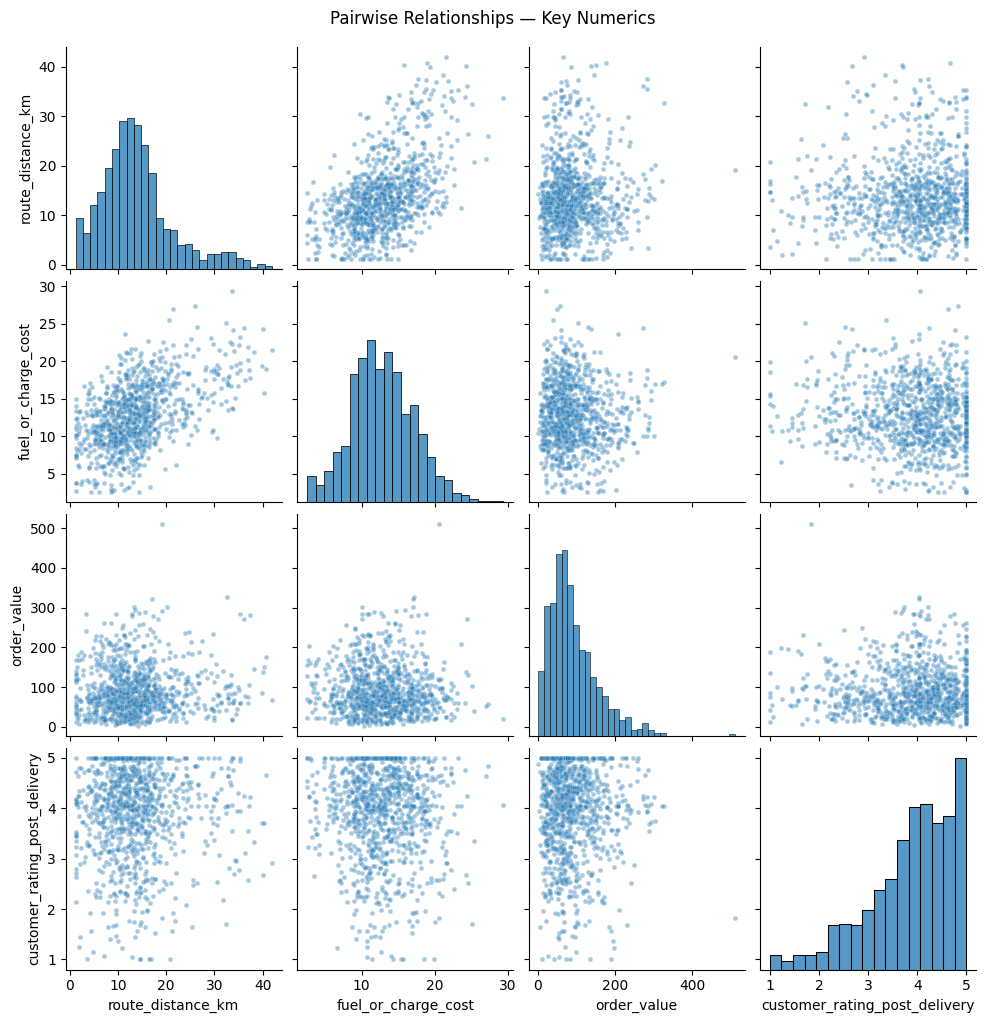

In [ ]:
# 10.3 Pair plot
sns.pairplot(od_numeric[['route_distance_km',
                         'fuel_or_charge_cost',
                         'order_value',
                         'customer_rating_post_delivery']],
             diag_kind="hist",
             plot_kws={"alpha": 0.4, "s": 12})
plt.suptitle("Pairwise Relationships — Key Numerics", y=1.02)
plt.show()

**Interpretation.** The pair plot confirms the distance/cost relationship visually and shows that order value and customer rating have no clean linear relationship with any other numeric.

## 11. Visualisations

 Plot 1: Delivery status breakdown by service type (Stacked bar)

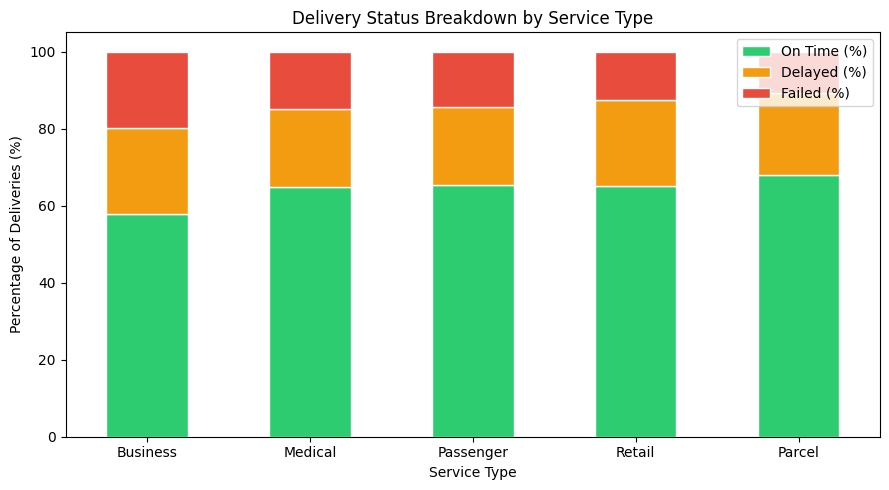

In [ ]:
merged_od = orders.merge(deliveries, on="order_id")

status_by_service_result = (
    merged_od
    .groupby("service_type")
    .agg(
        total_deliveries = ("delivery_id", "count"),
        on_time          = ("delivery_status", lambda x: (x == "OnTime").sum()),
        delayed          = ("delivery_status", lambda x: (x == "Delayed").sum()),
        failed           = ("delivery_status", lambda x: (x == "Failed").sum())
    )
    .assign(
        on_time_pct = lambda df: (df["on_time"] / df["total_deliveries"] * 100).round(2),
        delay_pct   = lambda df: (df["delayed"]  / df["total_deliveries"] * 100).round(2),
        failure_pct = lambda df: (df["failed"]   / df["total_deliveries"] * 100).round(2)
    )
    .sort_values("failure_pct", ascending=False)
    .reset_index()
)

status_plot = status_by_service_result.set_index("service_type")[["on_time_pct", "delay_pct", "failure_pct"]]
status_plot.columns = ["On Time (%)", "Delayed (%)", "Failed (%)"]

status_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#2ecc71", "#f39c12", "#e74c3c"],
    edgecolor="white"
)
plt.title("Delivery Status Breakdown by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Percentage of Deliveries (%)")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation.** Failure share is concentrated in specific service types rather than spread evenly — a clear target for operational review.

Plot 2: Training Score Band vs Failure Rate (Bar chart)

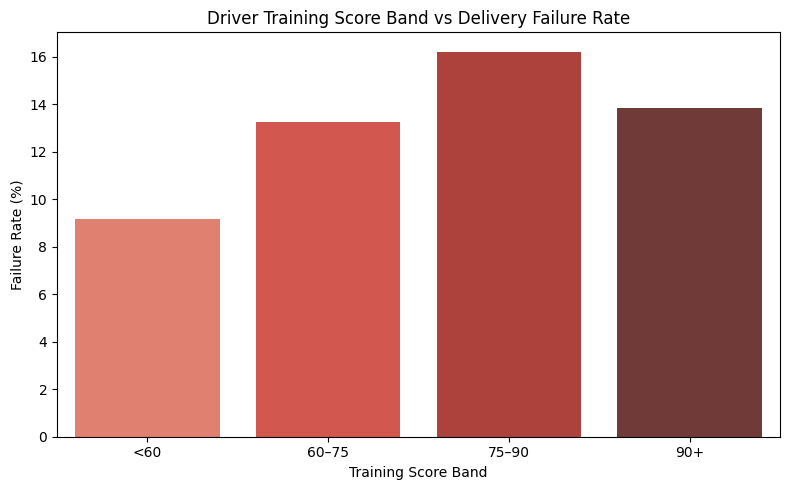

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=training_failure_result, x="training_band", y="failure_rate_percentage", hue="training_band", palette="Reds_d", legend=False)
plt.title("Driver Training Score Band vs Delivery Failure Rate")
plt.xlabel("Training Score Band")
plt.ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation.** Training band is not a clean predictor of failure rate — context matters as much as training.

Plot 3: Maintenance Status vs Incident Count

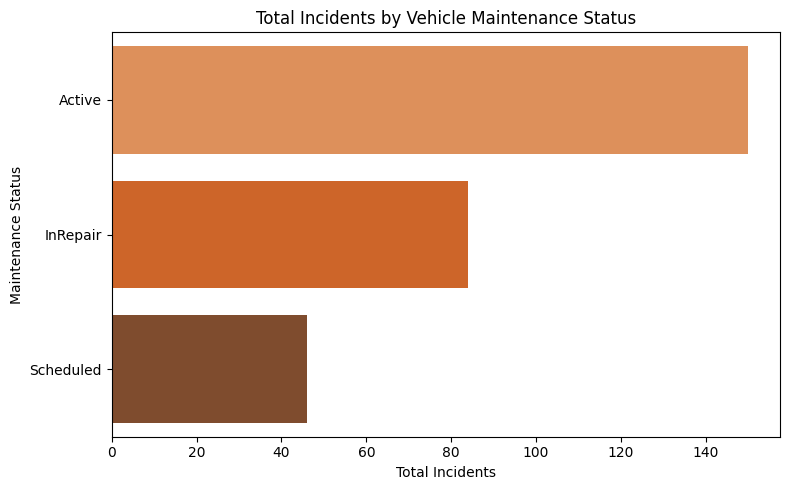

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=maintenance_incident_result, x="total_incidents", y="maintenance_status", hue="maintenance_status", palette="Oranges_d", legend=False)
plt.title("Total Incidents by Vehicle Maintenance Status")
plt.xlabel("Total Incidents")
plt.ylabel("Maintenance Status")
plt.tight_layout()
plt.show()

**Interpretation.** Vehicles in or needing maintenance accumulate more incidents — fleet condition feeds directly into operational risk.